In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor

from matplotlib import pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error

In [2]:
path = 'pre_processed (1).pkl'

df = pd.read_pickle(path)

In [3]:
df.shape

(8465, 16)

In [4]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Day', 'Month', 'Year', 'Weekend_or_Holiday'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8465 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8465 non-null   datetime64[ns]
 1   Rented Bike Count          8465 non-null   int64         
 2   Hour                       8465 non-null   category      
 3   Temperature(°C)            8465 non-null   float64       
 4   Humidity(%)                8465 non-null   int64         
 5   Wind speed (m/s)           8465 non-null   float64       
 6   Visibility (10m)           8465 non-null   int64         
 7   Dew point temperature(°C)  8465 non-null   float64       
 8   Solar Radiation (MJ/m2)    8465 non-null   float64       
 9   Rainfall(mm)               8465 non-null   float64       
 10  Snowfall (cm)              8465 non-null   float64       
 11  Seasons                    8465 non-null   category      
 12  Day        

In [6]:
categorical_cols = ['Hour', 'Seasons', 'Day', 'Month', 'Year', 'Weekend_or_Holiday']

encoder = OneHotEncoder(drop='first', sparse_output=False)
X_cat = encoder.fit_transform(df[categorical_cols])
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

In [7]:
numerical_cols = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
                  'Visibility (10m)', 'Dew point temperature(°C)',
                  'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

X_num = df[numerical_cols].values

In [8]:
X_encoded = np.hstack([X_num, X_cat])

feature_names = np.concatenate([numerical_cols, cat_feature_names])

In [9]:
y = df['Rented Bike Count'].values

In [10]:
print(f"X shape: {X_encoded.shape}")
print(f"y shape: {y.shape}")

X shape: (8465, 77)
y shape: (8465,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [12]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6772, 77)
X_test shape: (1693, 77)
y_train shape: (6772,)
y_test shape: (1693,)


In [13]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [15]:
grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    cv=5,
    scoring='r2',
    verbose=3
)

In [16]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300;, score=0.691 total time=   1.3s
[CV 2/5] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300;, score=0.679 total time=   1.3s
[CV 3/5] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300;, score=0.675 total time=   1.7s
[CV 4/5] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300;, score=0.696 total time=   2.2s
[CV 5/5] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300;, score=0.698 total time=   1.2s
[CV 1/5] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200;, score=0.863 total time=   1.6s
[CV 2/5] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200;, sc

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   scoring='r2', verbose=3)

In [17]:
best_rf = grid_search.best_estimator_

In [18]:
grid_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [19]:
y_pred = best_rf.predict(X_test)

In [20]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Test set R²: {r2:.6f}")
print(f"Test set MSE: {mse:.6f}")
print(f"Test set RMSE: {rmse:.6f}")

Test set R²: 0.864084
Test set MSE: 53358.808004
Test set RMSE: 230.995255


In [21]:
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importances.head(15))

Top 20 Most Important Features:
                      Feature  Importance
0             Temperature(°C)    0.166902
1                 Humidity(%)    0.087759
4   Dew point temperature(°C)    0.080064
33             Seasons_Winter    0.078606
5     Solar Radiation (MJ/m2)    0.073775
25                    Hour_18    0.065391
3            Visibility (10m)    0.036452
6                Rainfall(mm)    0.033059
2            Wind speed (m/s)    0.030334
26                    Hour_19    0.024270
11                     Hour_4    0.021758
28                    Hour_21    0.020087
32             Seasons_Summer    0.019648
68                    Month_6    0.018728
12                     Hour_5    0.017538


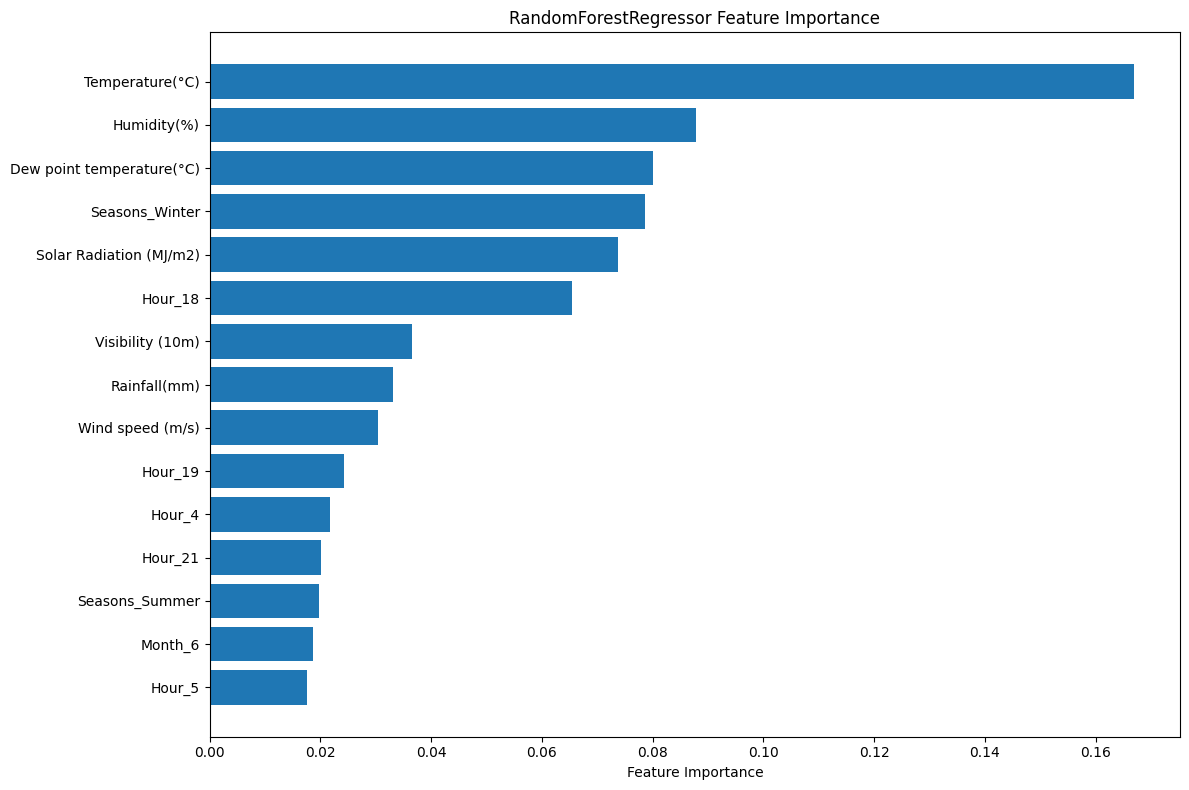

In [22]:
plt.figure(figsize=(12, 8))
top_features = feature_importances.head(15)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.title('RandomForestRegressor Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()